In [1]:
import numpy as np
from scipy.special import lambertw
import xarray as xr

def compute_LCL(T, qv, Rh, z, g=9.81, p0 = 1000*100):
    """
    Compute the LCL temperature and height from temperature, humidity, and geopotential.
    
    Parameters
    ----------
    T : array-like or xarray.DataArray
        Temperature at reference level (K)
    qv : array-like or xarray.DataArray
        Specific humidity at reference level (kg/kg)
    Rh : array-like or xarray.DataArray
        Relative humidity at reference level (0 to 1)
    z : array-like or xarray.DataArray
        Geopotential at reference level (m^2/s^2), will be divided by g to get height (m)
    g : float, optional
        Gravitational acceleration (m/s²), default is 9.81
    p : float, optional
        pressure level of input (default 1000 hPa)

    Returns
    -------
    TLCL : same shape as inputs
        Temperature at LCL (K)
    zLCL : same shape as inputs
        Height of LCL (m)
    """

    # Physical constants
    Ttr = 273.16  # Triple point temperature (K)
    E0v = 2.3740e6  # Latent heat of vaporization at Ttr (J/kg)
    cvl = 4119      # Specific heat liquid water (J/kg/K)
    cvv = 1418      # Specific heat water vapor (J/kg/K)
    Rv  = 461       # Gas constant for water vapor (J/kg/K)
    cpv = cvv + Rv
    Ra  = 287.04    # Gas constant for dry air (J/kg/K)
    cva = 719
    cpa = cva + Ra

    # Moist air specific gas constant and heat capacity
    Rm  = (1 - qv) * Ra + qv * Rv
    cpm = (1 - qv) * cpa + qv * cpv

    # Coefficients for LCL temperature equation
    a = cpm / Rm + (cvl - cpv) / Rv
    b = - (E0v - Ttr * (cvv - cvl)) / (Rv * T)
    c = b / a

    # Argument to Lambert W function
    RHcec = c * np.exp(c) * Rh**(1 / a)

    # Compute TLCL using -1 branch of Lambert W
    TLCL = T * c / lambertw(RHcec, k=-1).real

    # Compute zLCL from TLCL
    z = z / g  # convert geopotential to height
    zLCL = z + (cpm / g) * (T - TLCL)
    zLCL_old = z+cpm/g * (T-55-1/(1/(T-55)-np.log(Rh)/2840))
    
    pLCL =  p0 * (TLCL / T) ** (cpm / Rm)

    return TLCL, zLCL, pLCL


In [2]:
z_s = xr.open_dataset("/work/uc1275/u301827/02_MSE/surface_geopotential_zs.nc")
PARIS_LON = 13.4 #paris 2.35
PARIS_LAT = 52.52#paris 48.86
z_surface = z_s.z.sel(longitude=PARIS_LON, method = "nearest")\
                .sel(latitude=PARIS_LAT, method = 'nearest').values[0]

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.units import units

# Load and spatially average
ds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024_new.nc"
).mean(['lat', 'lon'])

# --- Relative humidity (unchanged) ---
t2m_units = ds.t2m * units.kelvin
td2m_units = ds.td2m * units.kelvin

ds["rh"] = mpcalc.relative_humidity_from_dewpoint(t2m_units, td2m_units)


In [4]:
TLCLmax, zLCLmax, pLCLmax = compute_LCL(ds.tasmax, ds.q.isel(lev = 0), ds.rh.values ,z_surface, p0 = ds.sp.values)

In [5]:
TLCL, zLCL, pLCL = compute_LCL(ds.t2m, ds.q.isel(lev = 0), ds.rh.values ,z_surface, p0 = ds.sp.values)

In [6]:
ds["pLCL"] = pLCL
ds["pLCLmax"] = pLCLmax

In [7]:
# Constants
R = 287.0       # J/kg/K, dry air gas constant
cp = 1004.0     # J/kg/K, dry air heat capacity
p_ref = 500e2   # 500 hPa in Pa

# Ensure surface pressure exists
ps = ds["sp"]      # surface pressure in Pa
T500 = ds["t"]# temperature at 500 hPa in K (replace with correct var)

# Compute theoretical upper bound
T_max_bound = T500 * (ps / p_ref)**(R / cp)


ds["t_bound"] = T_max_bound

ds["t_bound_mse"] = (-ds["mse"]+ds["mse_sat"])*1e3/cp



In [8]:
def pLCL_from_RH(Rh, T, qv, cpm, Rm, c, p0):
    """
    Compute pLCL from RH using Lambert-W formulation.
    Rh : relative humidity [0-1]
    T  : temperature at reference level [K]
    qv : specific humidity [kg/kg]
    cpm, Rm, c : precomputed coefficients from compute_LCL
    p0 : reference pressure (Pa)
    """
    from scipy.special import lambertw
    import numpy as np

    RHcec = c * np.exp(c) * Rh**(1 / a)
    TLCL = T * c / lambertw(RHcec, k=-1).real
    return p0 * (TLCL / T) ** (cpm / Rm)


In [9]:
# Final dataset
ds_era = ds
tasmax = ds["tasmax"]

# -----------------------------------------------------------
# 1. Find TXx date per year
# -----------------------------------------------------------
def get_txx_date(da):
    idx = da.argmax(dim="time")
    return da.time.isel(time=idx)

txx_dates = tasmax.groupby("time.year").apply(get_txx_date)

# Synthetic composite time axis: -3 ... +3
composite_time = xr.DataArray(np.arange(-3, 4), dims="time", name="time")

# -----------------------------------------------------------
# 2. Extract ±3-day windows and align to synthetic time axis
# -----------------------------------------------------------
composite_list = []

for year in txx_dates.year.values:
    txx_day = pd.to_datetime(str(txx_dates.sel(year=year).values))
    
    # Get 7 exact timestamps
    window_times = [txx_day + pd.Timedelta(days=i) for i in range(-3, 4)]
    
    # Select these exact times
    comp = ds.sel(time=window_times)
    
    # Replace actual timestamps by synthetic [-3..3]
    comp = comp.assign_coords(time=composite_time)
    
    # Add year coordinate
    comp = comp.expand_dims(composite_year=[year])
    
    composite_list.append(comp)

# Concatenate across years
composite_ds = xr.concat(composite_list, dim="composite_year")

composite_ds



<xarray.Dataset>
Dimensions:         (composite_year: 85, depth: 1, lev: 1, time: 7)
Coordinates:
  * composite_year  (composite_year) int64 1940 1941 1942 ... 2022 2023 2024
  * time            (time) int64 -3 -2 -1 0 1 2 3
    plev            float64 5e+04
  * lev             (lev) float64 137.0
  * depth           (depth) float64 0.0
Data variables: (12/23)
    t               (composite_year, time) float32 257.3 258.1 ... 261.6 264.5
    z               (composite_year, time) float32 5.69e+04 ... 5.726e+04
    q               (composite_year, time, lev) float32 0.007604 ... 0.01027
    tasmax          (composite_year, time) float32 299.1 301.3 ... 299.4 300.0
    t2m             (composite_year, time) float32 291.7 293.0 ... 295.4 294.8
    td2m            (composite_year, time) float32 282.7 282.8 ... 290.9 288.1
    ...              ...
    mse_sat         (composite_year, time) float32 321.0 322.3 ... 327.4 333.0
    rh              (composite_year, time) float32 <Quantity([[0.55599636 0.5...
    pLCL            (composite_year, time) float64 8.835e+04 ... 9.107e+04
    pLCLmax         (composite_year, time) float64 8.789e+04 ... 9.083e+04
    t_bound         (composite_year, time) float32 314.7 315.6 ... 319.1 323.1
    t_bound_mse     (composite_year, time, lev) float32 0.3924 -0.2977 ... 4.973

In [10]:
ds.mse

<xarray.DataArray 'mse' (time: 31047, lev: 1)>
array([[281.7285 ],
       [277.29367],
       [288.21637],
       ...,
       [290.17703],
       [290.12982],
       [291.22888]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1940-01-01 1940-01-02 ... 2024-12-31
    plev     float64 ...
  * lev      (lev) float64 137.0

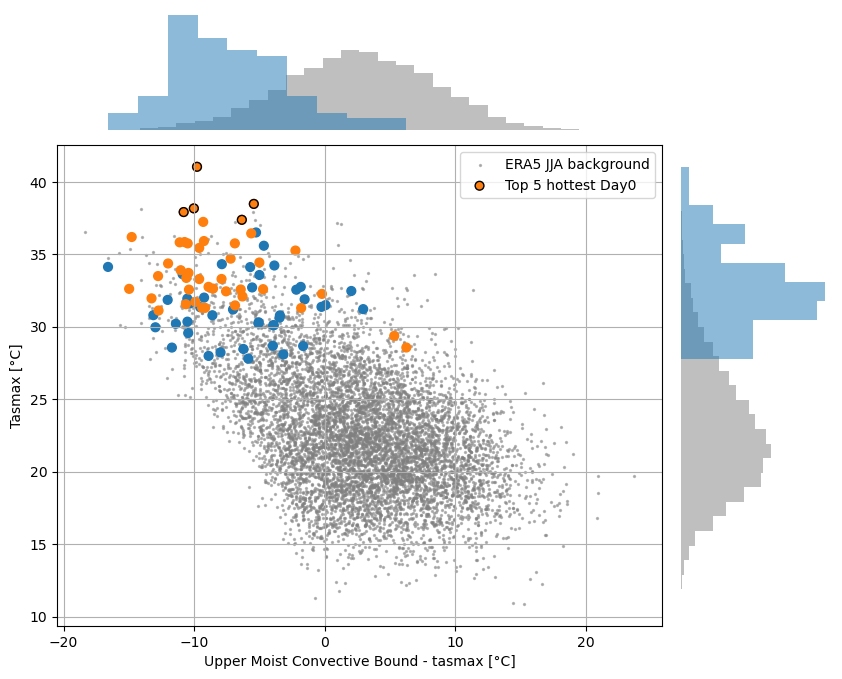

In [11]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound_mse"]
mse_era = tasmax_era#jja["rh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound_mse"]
mse = tasmax #ds["rh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Tasmax [°C]")
ax_scatter.set_xlabel("Upper Moist Convective Bound - tasmax [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tasmax_tboundmse_composite_day0_q_axis.pdf")
plt.show()


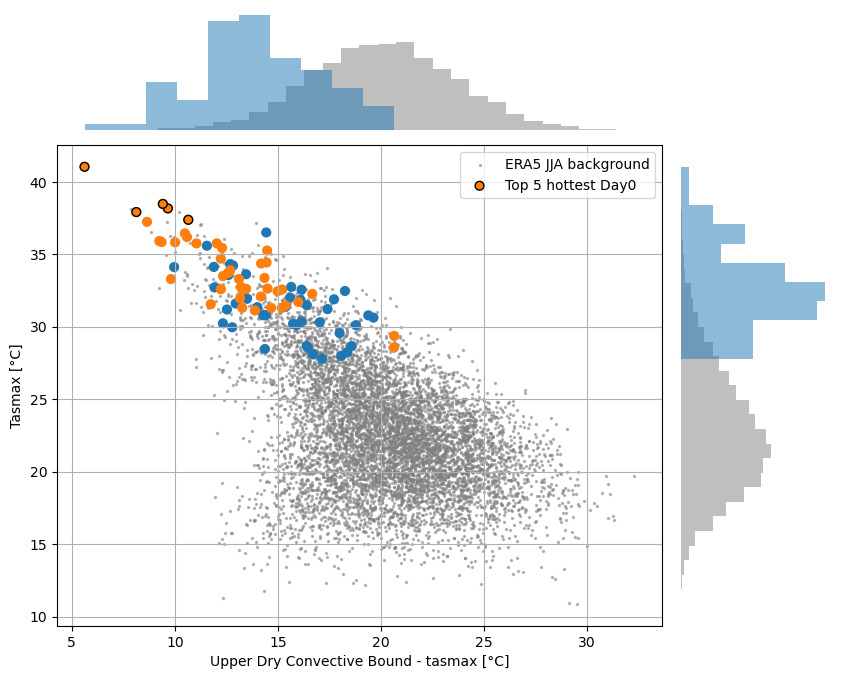

In [12]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"]- 273.15 - tasmax_era
mse_era = tasmax_era#jja["rh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound"] - 273.15 - tasmax
mse = tasmax #ds["rh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Tasmax [°C]")
ax_scatter.set_xlabel("Upper Dry Convective Bound - tasmax [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tasmax_tbound_composite_day0_q_axis.pdf")
plt.show()


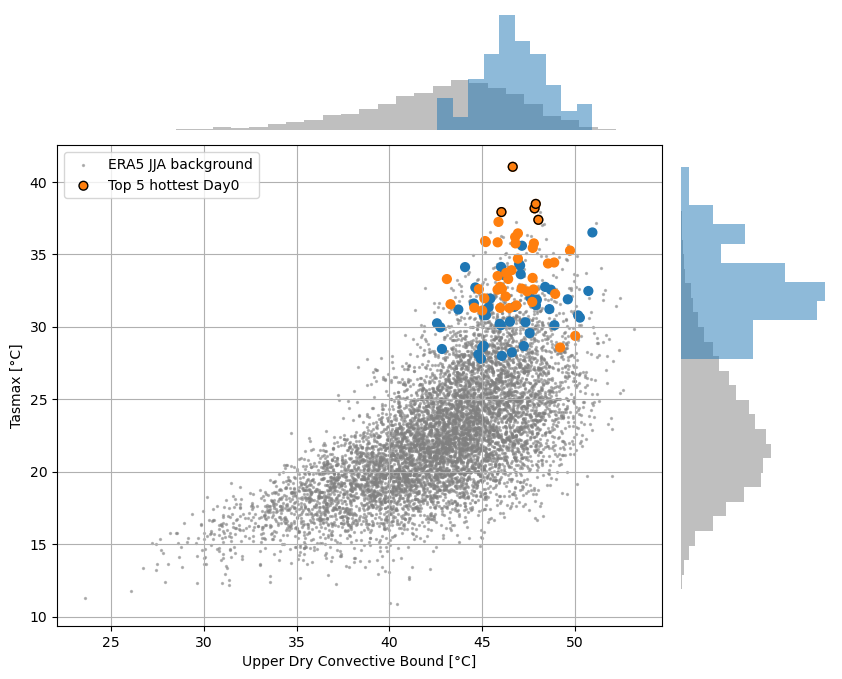

In [13]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"]- 273.15 
mse_era = tasmax_era#jja["rh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound"] - 273.15
mse = tasmax #ds["rh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Tasmax [°C]")
ax_scatter.set_xlabel("Upper Dry Convective Bound [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tasmax_plcl_composite_day0_q_axis.pdf")
plt.show()


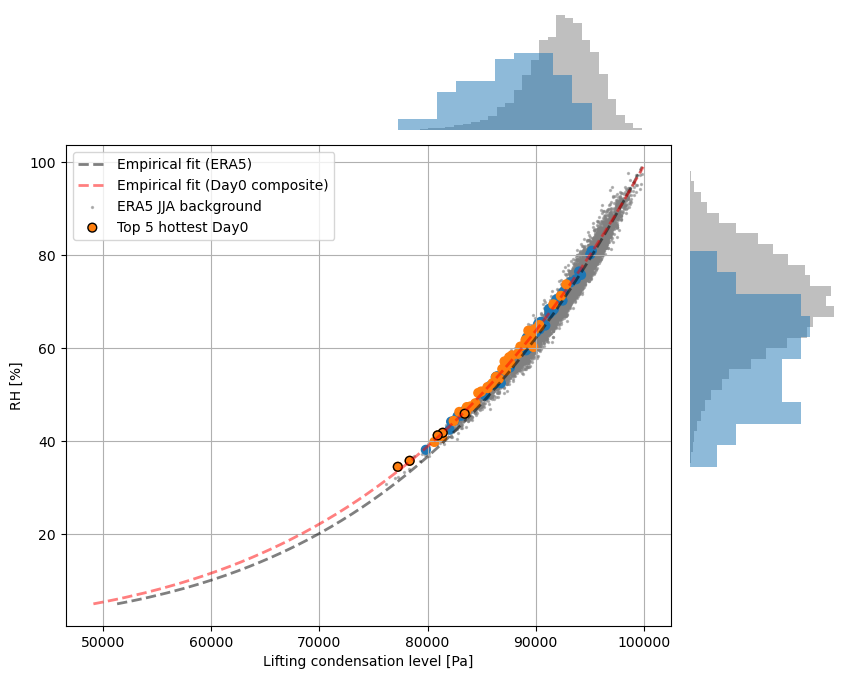

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja["pLCL"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["pLCL"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Lifting condensation level [Pa]")
ax_scatter.grid()
ax_scatter.legend()

from scipy.optimize import curve_fit

def plcl_model(RH, alpha, beta):
    return alpha * RH**beta

# ----------------------------
# 1. Fit for whole ensemble (ERA5)
# ----------------------------
mask_all = (x_era > 0) & (y_era > 0)
xdata_all = x_era[mask_all] / 100  # normalize RH to 0-1
ydata_all = y_era[mask_all]        # pLCL in Pa

# log-log fit for stability
log_x_all = np.log(xdata_all)
log_y_all = np.log(ydata_all)
coeffs_all = np.polyfit(log_x_all, log_y_all, 1)
beta_all = coeffs_all[0]
alpha_all = np.exp(coeffs_all[1])

RH_fit = np.linspace(0.05, 0.99, 200)
pLCL_fit_all = alpha_all * RH_fit**beta_all
ax_scatter.plot(pLCL_fit_all, RH_fit*100, 'k--', lw=2, alpha = 0.5, label='Empirical fit (ERA5)')

# ----------------------------
# 2. Fit for colored points (Day 0 composite)
# ----------------------------
mask_colored = pos | neg  # all colored points
xdata_col = x[mask_colored] / 100
ydata_col = y[mask_colored]

log_x_col = np.log(xdata_col)
log_y_col = np.log(ydata_col)
coeffs_col = np.polyfit(log_x_col, log_y_col, 1)
beta_col = coeffs_col[0]
alpha_col = np.exp(coeffs_col[1])

pLCL_fit_col = alpha_col * RH_fit**beta_col
ax_scatter.plot(pLCL_fit_col, RH_fit*100, 'r--', lw=2, alpha = 0.5, label='Empirical fit (Day0 composite)')

ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("rh_plcl_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t"]
mse_era = tasmax_era#jja["rh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t"]
mse = tasmax #ds["rh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Tasmax [°C]")
ax_scatter.set_xlabel("T500 [K]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
#plt.savefig("tasmax_plcl_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"] - 273.15-tasmax_era
mse_era = jja["swvl1"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q =ds["t_bound"] - 273.15 -tasmax
mse = ds["swvl1"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("swvl1 [m3/m3]")
ax_scatter.set_xlabel("Upper Dry Convective Bound -tasmax [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tbound_soil_moisture_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"] - 273.15 - tasmax_era
mse_era = jja["q"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound"] - 273.15 - tasmax
mse = ds["q"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("q [kg/kg]")
ax_scatter.set_xlabel("Upper Dry Convective Bound [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tbound_q_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"] - 273.15 
mse_era = jja["blh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound"] - 273.15
mse = ds["blh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("blh [m]")
ax_scatter.set_xlabel("Upper Dry Convective Bound [°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
#plt.savefig("tasmax_plcl_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = jja["t_bound"] - 273.15 -tasmax_era
mse_era = jja["blh"]

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["t_bound"] - 273.15 - tasmax
mse = ds["blh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("blh [m]")
ax_scatter.set_xlabel("Upper Dry Convective Bound - tasmax[°C]")
ax_scatter.grid()
ax_scatter.legend()


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("tbound_blh_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr
from sklearn.linear_model import LinearRegression

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
tasmax_era = jja["tasmax"] - 273.15
q_era = tasmax_era 

mse_diff_era = mse_era - mse_sat_era

# Flatten and mask NaNs
x_era = mse_era.values.ravel()
y_era = q_era.values.ravel()
c_era = mse_diff_era.values.ravel()
mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era, y_era, c_era = x_era[mask], y_era[mask], c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = tasmax
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()  # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()    # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("tasmax [°C]")
ax_scatter.set_ylabel("RH [%]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Optional: RH at Tmax bound (linear regression)
# -------------------------------------------------------------
# Weighted linear regression emphasizing dry extremes
from sklearn.linear_model import LinearRegression

X = y_era.reshape(-1, 1)  # tasmax
Y = x_era                 # RH

# Emphasize both dry and very humid extremes
Y_norm = (Y - np.mean(Y)) / np.std(Y)   # normalize
weights = np.abs(Y_norm) ** 2          # optional: square to emphasize more

# Fit weighted linear regression
model = LinearRegression()
model.fit(X, Y, sample_weight=weights)

# Compute regression line for plotting
x_line = np.linspace(y_era.min(), y_era.max()+10, 200)
y_line = model.predict(x_line.reshape(-1, 1))

# Plot weighted regression line
ax_scatter.plot(x_line, y_line, color='red', linewidth=2, label='Weighted Fit (dry extremes)')
ax_scatter.legend()



# -------------------------------------------------------------
# 6. Marginal histograms (aligned bins)
# -------------------------------------------------------------
# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=bins_x, color='tab:blue', alpha=0.7, density=True)
ax_histx.axis('off')
ax_histx.set_xlim(ax_scatter.get_xlim())

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, orientation='horizontal', density=True)
ax_histy.hist(x, bins=bins_y, color='tab:blue', alpha=0.7, orientation='horizontal', density=True)
ax_histy.axis('off')
ax_histy.set_ylim(ax_scatter.get_ylim())


#plt.tight_layout()
plt.savefig("rh_tasmax_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import xarray as xr
import numpy as np

# Constants
R = 287.0       # J/kg/K, dry air gas constant
cp = 1004.0     # J/kg/K, dry air heat capacity
p_ref = 500e2   # 500 hPa in Pa

# Ensure surface pressure exists
ps = ds_era["sp"].sel(time=ds_era.time.dt.month.isin([6, 7, 8]))       # surface pressure in Pa
T500 = ds_era["t"].sel(time=ds_era.time.dt.month.isin([6, 7, 8])) # temperature at 500 hPa in K (replace with correct var)

# Compute theoretical upper bound
T_max_bound = T500 * (ps / p_ref)**(R / cp)

# Maximum value in the dataset
max_T_bound = T_max_bound.max().item()

print("Maximum theoretical T upper bound [K]:", max_T_bound-273.15)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr
from sklearn.linear_model import LinearRegression

# -------------------------------------------------------------
# Function: Convert BLH in meters to pressure (Pa)
# -------------------------------------------------------------
def blh_to_pressure(blh, sp, T):
    g = 9.81       # m/s²
    R_d = 287.05   # J/(kg·K)
    return sp * np.exp(- g * blh / (R_d * T))

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

blh_era_m = jja["blh"].values
sp_era = jja["sp"].values
T_era = jja["tasmax"].values # ensure in K
blh_era = blh_to_pressure(blh_era_m, sp_era, T_era)  # Y-axis: BLH in Pa

q_era = jja["pLCL"].values             # X-axis: LCL in Pa
mse_sat_era = jja["mse_sat"].values
mse_diff_era = blh_era - mse_sat_era

# Flatten and mask NaNs
x_era = blh_era.ravel()
y_era = q_era.ravel()
c_era = mse_diff_era.ravel()
mask = ~np.isnan(x_era) & ~np.isnan(y_era)
x_era, y_era, c_era = x_era[mask], y_era[mask], c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"].values # K
sp = ds["sp"].values
blh_m = ds["blh"].values
blh = blh_to_pressure(blh_m, sp, tasmax)      # BLH in Pa
q = ds["pLCL"].values                          # LCL in Pa
mse_sat = ds["mse_sat"].values

def flatten(da):
    return da.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
blh_flat = flatten(blh)
mse_diff_flat = flatten(blh - mse_sat)

# Day 0
ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

day0_idx = 3
x = blh_flat[:, day0_idx, :].ravel()
y = q_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# Scatter plot
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Boundary layer height [Pa]")
ax_scatter.set_xlabel("Lifting condensation level [Pa]")
ax_scatter.grid()


# -------------------------------------------------------------
# 5. Marginal histograms (aligned bins)
# -------------------------------------------------------------
bins_x = np.linspace(min(y_era.min(), y.min()), max(y_era.max(), y.max()), 30)
bins_y = np.linspace(min(x_era.min(), x.min()), max(x_era.max(), x.max()), 30)

ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=bins_x, color='tab:blue', alpha=0.7, density=True)
ax_histx.axis('off')
ax_histx.set_xlim(ax_scatter.get_xlim())

ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, orientation='horizontal', density=True)
ax_histy.hist(x, bins=bins_y, color='tab:blue', alpha=0.7, orientation='horizontal', density=True)
ax_histy.axis('off')
ax_histy.set_ylim(ax_scatter.get_ylim())

plt.savefig("blh_plcl_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr


# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["blh"]
mse_sat_era = jja["mse_sat"]
q_era = jja["pLCL"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["pLCL"] 
mse = ds["blh"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("Boundary layer height [m]")
ax_scatter.set_xlabel("Lifting condensation level [Pa]")
ax_scatter.grid()
ax_scatter.legend()

from scipy.optimize import curve_fit

def plcl_model(RH, alpha, beta):
    return alpha * RH**beta


# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("blh_plcl_composite_day0_q_axis.pdf")
plt.show()


In [ ]:
# Select Day 0
tas_day0 = composite_ds["tasmax"].sel(time=0) - 273.15

# Spatial mean per composite year
tas_day0_mean = tas_day0.mean(dim=[d for d in tas_day0.dims if d != "composite_year"])

# Top 5 composite years
top5_tas_idx = tas_day0_mean.argsort().values[-5:][::-1]
top5_years = composite_ds.composite_year.values[top5_tas_idx]

print("Top 5 hottest tasmax events (Day 0):")
for y in top5_years:
    date = pd.to_datetime(str(txx_dates.sel(year=y).values))
    val = tas_day0_mean.sel(composite_year=y).values
    print(f"{date.date()} (year {y}) : {val:.2f} °C")


In [ ]:
# Select Day 0
q_day0 = composite_ds["t_bound"].sel(time=0) - 273.15

# Surface level if present
if "lev" in q_day0.dims:
    q_day0 = q_day0.isel(lev=0)

# Spatial mean per composite year
q_day0_mean = q_day0.mean(dim=[d for d in q_day0.dims if d != "composite_year"])

# Top 5 composite years
top5_q_idx = q_day0_mean.argsort().values[-5:][::-1]
top5_years_q = composite_ds.composite_year.values[top5_q_idx]

print("\nTop 5 highest t_bound events (Day 0):")
for y in top5_years_q:
    date = pd.to_datetime(str(txx_dates.sel(year=y).values))
    val = q_day0_mean.sel(composite_year=y).values
    print(f"{date.date()} (year {y}) : {val:.2f} °C")


In [ ]:
import pandas as pd
import xarray as xr
import numpy as np

# --------------------------------------------------
# Settings
# --------------------------------------------------
out_file = "txx_day0_top5_extremes.nc"

# --------------------------------------------------
# 1. TASMAX – Day 0
# --------------------------------------------------
tas_day0 = composite_ds["tasmax"].sel(time=0) - 273.15

tas_day0_mean = tas_day0.mean(
    dim=[d for d in tas_day0.dims if d != "composite_year"]
)

top5_tas_idx = tas_day0_mean.argsort().values[-5:][::-1]
top5_tas_years = composite_ds.composite_year.values[top5_tas_idx]

tas_dates = [
    pd.to_datetime(str(txx_dates.sel(year=y).values)) for y in top5_tas_years
]

# --------------------------------------------------
# 2. T_BOUND – Day 0
# --------------------------------------------------
q_day0 = composite_ds["t_bound"].sel(time=0) - 273.15

if "lev" in q_day0.dims:
    q_day0 = q_day0.isel(lev=0)

q_day0_mean = q_day0.mean(
    dim=[d for d in q_day0.dims if d != "composite_year"]
)

top5_q_idx = q_day0_mean.argsort().values[-5:][::-1]
top5_q_years = composite_ds.composite_year.values[top5_q_idx]

q_dates = [
    pd.to_datetime(str(txx_dates.sel(year=y).values)) for y in top5_q_years
]

# --------------------------------------------------
# 3. Build output Dataset
# --------------------------------------------------
extremes_ds = xr.Dataset(
    {
        "tasmax_day0": ("rank", tas_day0_mean.sel(composite_year=top5_tas_years).values),
        "tasmax_date": ("rank", np.array(tas_dates, dtype="datetime64[ns]")),
        "tasmax_year": ("rank", top5_tas_years),

        "t_bound_day0": ("rank", q_day0_mean.sel(composite_year=top5_q_years).values),
        "t_bound_date": ("rank", np.array(q_dates, dtype="datetime64[ns]")),
        "t_bound_year": ("rank", top5_q_years),
    },
    coords={"rank": np.arange(1, 6)}
)

# --------------------------------------------------
# 4. Save
# --------------------------------------------------
extremes_ds.to_netcdf(out_file)
print(f"Saved extremes to {out_file}")
